# Telco Customer Churn Prediction

## Project Overview

This project analyzes customer churn in a telecommunications dataset and develops machine learning models to identify customers at higher risk of leaving.

The workflow combines:

- Business understanding
- Data quality assessment
- Data cleaning
- Exploratory data analysis
- Leakage prevention
- Feature preprocessing
- Classification modeling
- Model evaluation
- Model interpretation
- Business recommendations

The primary business objective is to identify potential churners so that customer-retention teams can prioritize proactive interventions.

In [18]:
from pathlib import Path
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    RocCurveDisplay,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

RANDOM_STATE = 42
warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda value: f"{value:.3f}")
sns.set_theme(style="whitegrid")

ROOT = Path.cwd().resolve()
if not (ROOT / "data" / "raw").exists():
    ROOT = ROOT.parent
RAW = ROOT / "data" / "raw"
OUT = ROOT / "outputs"
FIGURES = OUT / "figures"
OUT.mkdir(exist_ok=True)
FIGURES.mkdir(exist_ok=True, parents=True)

print(f"Project root: {ROOT}")
print(f"Raw data folder: {RAW}")

Project root: /workspaces/customer-churn-prediction
Raw data folder: /workspaces/customer-churn-prediction/data/raw


## 1. Data Loading and Initial Assessment

The dataset is loaded from the project's raw-data directory. Before cleaning, we inspect its dimensions, column names, data types, descriptive statistics, and missing values to understand the data quality and structure.

## 2. Data Cleaning and Feature Selection

The source data is standardized, numeric fields are converted, and the churn label is encoded as a binary target. Leakage variables derived from churn, undocumented `CLTV`, redundant constants, customer identifiers, and geographic fields are excluded so that predictions rely on information plausibly available before intervention.

In [19]:
excel_path = RAW / "Telco_customer_churn.xlsx"
if not excel_path.exists():
    raise FileNotFoundError(f"No Excel dataset found at {excel_path}")

df = pd.read_excel(excel_path)
print(f"Loaded {excel_path.relative_to(ROOT)} | shape={df.shape}")
print("\nColumns:\n", df.columns.tolist())
print("\nData types:\n", df.dtypes)
print("\nBasic statistics:\n", df.describe(include="all").transpose())

missing_summary = (
    df.isna().sum().sort_values(ascending=False).to_frame("Missing Values")
)
missing_summary["Missing %"] = (missing_summary["Missing Values"] / len(df) * 100).round(2)
print("\nMissing values:\n")
display(missing_summary[missing_summary["Missing Values"] > 0])
print("Duplicate rows:", df.duplicated().sum())

df.columns = df.columns.str.strip()
df = df.rename(columns={
    "CustomerID": "customerID",
    "Tenure Months": "tenure",
    "Total Charges": "TotalCharges",
    "Monthly Charges": "MonthlyCharges",
    "Churn Label": "Churn",
})

leakage_cols = ["Churn Value", "Churn Score", "Churn Reason"]
redundant_cols = ["Count", "Country", "State", "CLTV"]
geographic_cols = ["City", "Zip Code", "Lat Long", "Latitude", "Longitude"]
for col in leakage_cols + redundant_cols + geographic_cols:
    if col in df.columns:
        df = df.drop(columns=col)

if "TotalCharges" in df:
    df["TotalCharges"] = pd.to_numeric(
        df["TotalCharges"].replace(r"^\s*$", np.nan, regex=True), errors="coerce"
    )
if "customerID" in df:
    df = df.drop(columns="customerID")
if "Churn" not in df:
    raise ValueError("Expected a Churn column")
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0}).astype("int8")

removed_predictors = set(leakage_cols + geographic_cols + ["CLTV"]).intersection(df.columns)
if removed_predictors:
    raise AssertionError(f"Excluded predictors remain: {sorted(removed_predictors)}")
print("\nLeakage, CLTV, and geographic predictors excluded successfully.")
print("Remaining columns:\n", df.columns.tolist())
print("\nMissing values after cleaning (remaining values are imputed in pipelines):\n",
      df.isna().sum().sort_values(ascending=False))
df.head()

Loaded data/raw/Telco_customer_churn.xlsx | shape=(7043, 33)

Columns:
 ['CustomerID', 'Count', 'Country', 'State', 'City', 'Zip Code', 'Lat Long', 'Latitude', 'Longitude', 'Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Tenure Months', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method', 'Monthly Charges', 'Total Charges', 'Churn Label', 'Churn Value', 'Churn Score', 'CLTV', 'Churn Reason']

Data types:
 CustomerID               str
Count                  int64
Country                  str
State                    str
City                     str
Zip Code               int64
Lat Long                 str
Latitude             float64
Longitude            float64
Gender                   str
Senior Citizen           str
Partner                  str
Dependents               str
Tenure Months          int64
Phone Service    

,Missing Values,Missing %
Churn Reason,5174,73.460


Duplicate rows: 0

Leakage, CLTV, and geographic predictors excluded successfully.
Remaining columns:
 ['Gender', 'Senior Citizen', 'Partner', 'Dependents', 'tenure', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method', 'MonthlyCharges', 'TotalCharges', 'Churn']

Missing values after cleaning (remaining values are imputed in pipelines):
 TotalCharges         11
Gender                0
Partner               0
Senior Citizen        0
Dependents            0
tenure                0
Multiple Lines        0
Phone Service         0
Online Security       0
Online Backup         0
Device Protection     0
Internet Service      0
Tech Support          0
Streaming TV          0
Contract              0
Streaming Movies      0
Paperless Billing     0
Payment Method        0
MonthlyCharges        0
Churn                 0
dtype: int64


,Gender,Senior Citizen,Partner,Dependents,tenure,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,MonthlyCharges,TotalCharges,Churn
0,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.850,108.150,1
1,Female,No,No,Yes,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.700,151.650,1
2,Female,No,No,Yes,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.650,820.500,1
3,Female,No,Yes,Yes,28,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.800,3046.050,1
4,Male,No,No,Yes,49,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.700,5036.300,1


## 3. Exploratory Data Analysis

The exploratory analysis focuses on identifying customer segments and behavioral patterns associated with churn. Because the dataset contains substantially more non-churned customers, churn rates rather than raw counts are used when comparing segments.

Overall churn rate: 26.5%


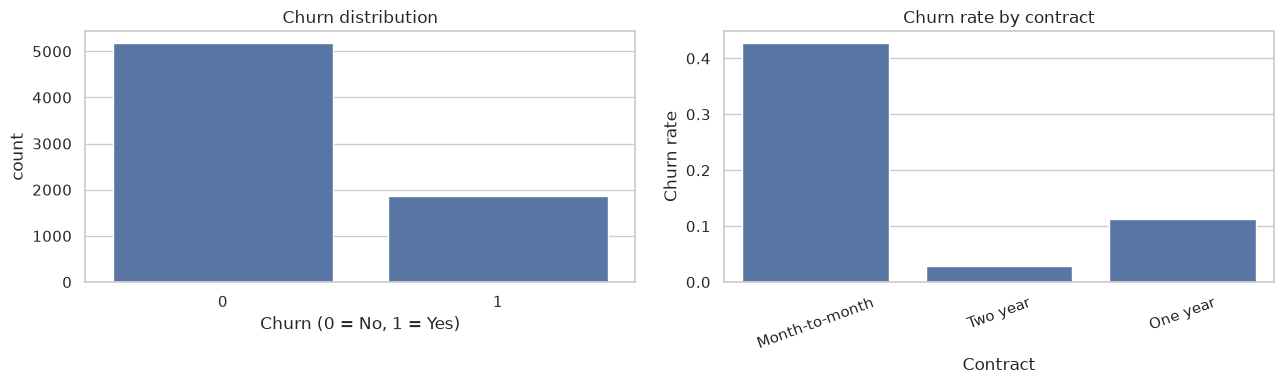

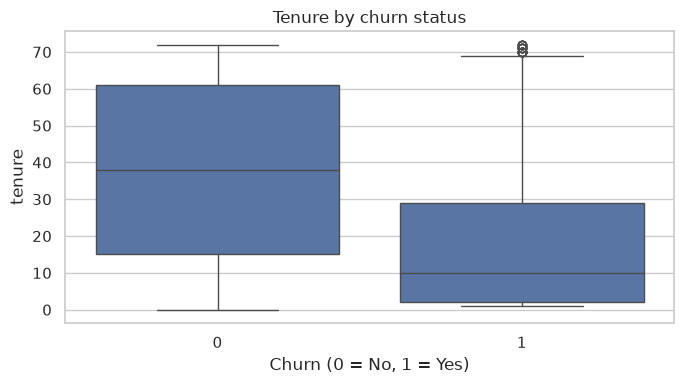

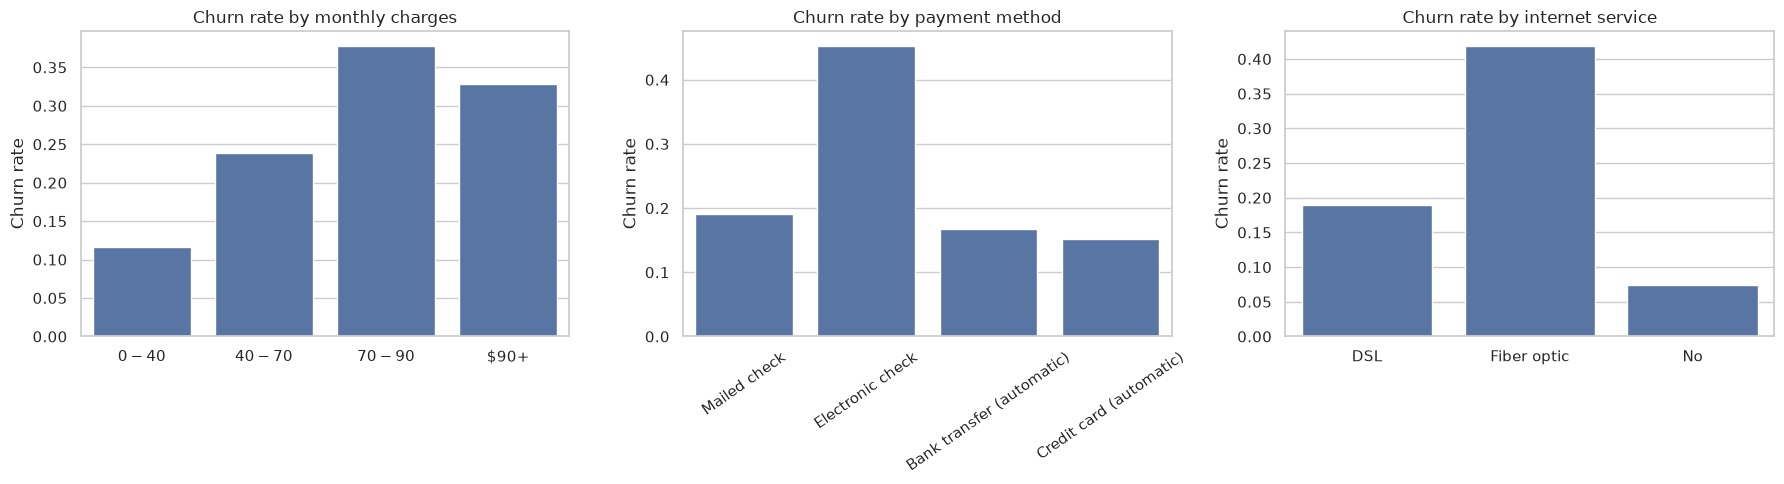


Churn rate by contract:


,Churn Rate (%),Customers
Contract,,
Month-to-month,42.710,3875
One year,11.270,1473
Two year,2.832,1695


Churn rate by payment method:


,Churn Rate (%),Customers
Payment Method,,
Electronic check,45.285,2365
Mailed check,19.107,1612
Bank transfer (automatic),16.710,1544
Credit card (automatic),15.243,1522


Churn rate by internet service:


,Churn Rate (%),Customers
Internet Service,,
Fiber optic,41.893,3096
DSL,18.959,2421
No,7.405,1526


Highest churn segment:
{'contract': 'Month-to-month', 'payment_method': 'Electronic check', 'internet_service': 'Fiber optic'}


In [20]:
overall_churn_rate = df["Churn"].mean() * 100
print(f"Overall churn rate: {overall_churn_rate:.1f}%")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.countplot(data=df, x="Churn", ax=axes[0])
axes[0].set_title("Churn distribution")
axes[0].set_xlabel("Churn (0 = No, 1 = Yes)")

if "Contract" in df:
    sns.barplot(data=df, x="Contract", y="Churn", errorbar=None, ax=axes[1])
    axes[1].set_ylabel("Churn rate")
    axes[1].tick_params(axis="x", rotation=20)
    axes[1].set_title("Churn rate by contract")

plt.tight_layout()
fig.savefig(FIGURES / "eda.png", dpi=150)
display(fig)
plt.close(fig)

if "tenure" in df:
    fig = plt.figure(figsize=(7, 4))
    sns.boxplot(data=df, x="Churn", y="tenure")
    plt.title("Tenure by churn status")
    plt.xlabel("Churn (0 = No, 1 = Yes)")
    plt.tight_layout()
    fig.savefig(FIGURES / "tenure_by_churn.png", dpi=150)
    display(fig)
    plt.close(fig)

# Business drivers: compare churn rates across actionable customer segments.
eda_df = df.copy()
eda_df["Monthly charge band"] = pd.cut(
    eda_df["MonthlyCharges"],
    bins=[0, 40, 70, 90, np.inf],
    labels=["$0-$40", "$40-$70", "$70-$90", "$90+"],
)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.barplot(data=eda_df, x="Monthly charge band", y="Churn", errorbar=None, ax=axes[0])
axes[0].set_title("Churn rate by monthly charges")
axes[0].set_ylabel("Churn rate")
axes[0].set_xlabel("")

sns.barplot(data=eda_df, x="Payment Method", y="Churn", errorbar=None, ax=axes[1])
axes[1].set_title("Churn rate by payment method")
axes[1].set_ylabel("Churn rate")
axes[1].set_xlabel("")
axes[1].tick_params(axis="x", rotation=35)

sns.barplot(data=eda_df, x="Internet Service", y="Churn", errorbar=None, ax=axes[2])
axes[2].set_title("Churn rate by internet service")
axes[2].set_ylabel("Churn rate")
axes[2].set_xlabel("")

plt.tight_layout()
fig.savefig(FIGURES / "business_churn_drivers.png", dpi=150)
display(fig)
plt.close(fig)

def churn_rate_table(column):
    return (
        df.groupby(column, observed=False)["Churn"]
        .agg(Churn_Rate="mean", Customers="count")
        .assign(Churn_Rate=lambda table: table["Churn_Rate"] * 100)
        .sort_values("Churn_Rate", ascending=False)
        .rename(columns={"Churn_Rate": "Churn Rate (%)"})
    )

print("\nChurn rate by contract:")
display(churn_rate_table("Contract"))
print("Churn rate by payment method:")
display(churn_rate_table("Payment Method"))
print("Churn rate by internet service:")
display(churn_rate_table("Internet Service"))

print("Highest churn segment:")
print({
    "contract": churn_rate_table("Contract").index[0],
    "payment_method": churn_rate_table("Payment Method").index[0],
    "internet_service": churn_rate_table("Internet Service").index[0],
})

### EDA Findings

The exploratory analysis highlights the clearest churn patterns in the customer base:

- Month-to-month customers show materially higher churn than customers on longer contracts.
- Customers with shorter tenure are more likely to churn.
- Higher monthly charges are associated with increased churn risk.
- Electronic-check users show higher observed churn than other payment groups.
- Fiber-optic customers show elevated churn in this dataset.

These patterns motivate the machine-learning stage, where multiple customer attributes are modeled together to estimate churn risk.

## 4. Machine Learning Pipeline

The target is binary: `0` indicates that a customer stayed and `1` indicates churn. Logistic Regression provides an interpretable baseline, while Random Forest can capture nonlinear relationships and interactions. Both models use class weighting to give additional importance to the minority churn class.

Preprocessing is performed inside each scikit-learn pipeline to prevent test-set information from influencing training-time transformations. Numerical features are median-imputed and standardized; categorical features are most-frequent-imputed and one-hot encoded with unknown categories ignored.

In [21]:
X, y = df.drop(columns="Churn"), df["Churn"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")
print(f"Training churn rate: {y_train.mean():.3f}")
print(f"Testing churn rate: {y_test.mean():.3f}")

numeric_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(exclude=np.number).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline([
                ("impute", SimpleImputer(strategy="median")),
                ("scale", StandardScaler()),
            ]),
            numeric_features,
        ),
        (
            "cat",
            Pipeline([
                ("impute", SimpleImputer(strategy="most_frequent")),
                ("encode", OneHotEncoder(handle_unknown="ignore")),
            ]),
            categorical_features,
        ),
    ]
)

estimators = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        # Class weighting gives greater importance to the minority churn class.
        class_weight="balanced",
        random_state=RANDOM_STATE,
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=250,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
}

fitted = {}
rows = []

for name, estimator in estimators.items():
    model = Pipeline([
        ("preprocessor", preprocessor),
        ("model", estimator),
    ])
    model.fit(X_train, y_train)

    pred = model.predict(X_test)
    prob = model.predict_proba(X_test)[:, 1]

    rows.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred, zero_division=0),
        "Recall": recall_score(y_test, pred, zero_division=0),
        "F1-score": f1_score(y_test, pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, prob),
    })

    fitted[name] = (model, prob)
    print(f"\n{name}\n")
    print(classification_report(y_test, pred, zero_division=0))
    print("Confusion matrix:\n", confusion_matrix(y_test, pred))

comparison = pd.DataFrame(rows).set_index("Model").sort_values("ROC-AUC", ascending=False)
print("\nModel comparison:\n", comparison.round(3))
comparison.to_csv(OUT / "model_comparison.csv")

Training samples: 5634
Testing samples: 1409
Training churn rate: 0.265
Testing churn rate: 0.265

Logistic Regression

              precision    recall  f1-score   support

           0       0.90      0.73      0.81      1035
           1       0.51      0.78      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.74      0.76      1409

Confusion matrix:
 [[755 280]
 [ 82 292]]

Random Forest

              precision    recall  f1-score   support

           0       0.87      0.83      0.85      1035
           1       0.57      0.65      0.61       374

    accuracy                           0.78      1409
   macro avg       0.72      0.74      0.73      1409
weighted avg       0.79      0.78      0.78      1409

Confusion matrix:
 [[854 181]
 [132 242]]

Model comparison:
                      Accuracy  Precision  Recall  F1-score  ROC-AUC
Model                                 

## 5. Model Evaluation and Selection

The final holdout test set is used for unbiased evaluation. Models are compared using accuracy, precision, recall, F1-score, and ROC-AUC. ROC-AUC is the primary selection metric because it evaluates ranking quality across classification thresholds, while recall remains important for finding customers who may churn.

The confusion matrices show the operational trade-off: false negatives are customers who churned but were not identified, while false positives represent customers who would receive an unnecessary retention intervention.

### Model Interpretation

For Logistic Regression, coefficients describe directional associations after preprocessing: positive coefficients are associated with higher predicted churn and negative coefficients with lower predicted churn. These associations should not be interpreted as causal effects.

Selected model based on ROC-AUC: Logistic Regression
ROC-AUC: 0.849
Recall: 0.781


,Accuracy,Precision,Recall,F1-score,ROC-AUC
Model,,,,,
Logistic Regression,0.743,0.510,0.781,0.617,0.849
Random Forest,0.778,0.572,0.647,0.607,0.834


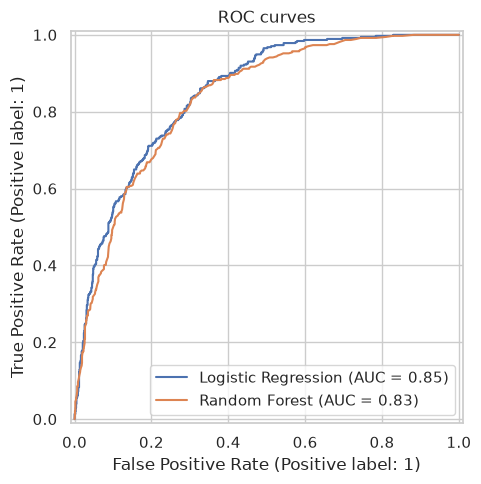

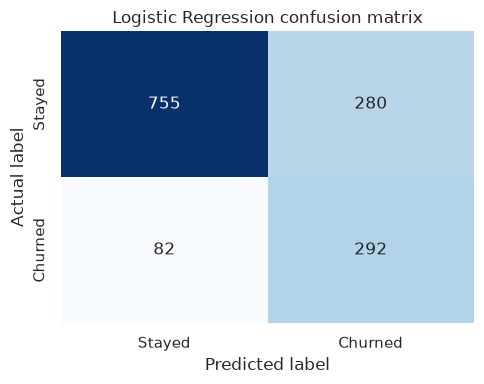

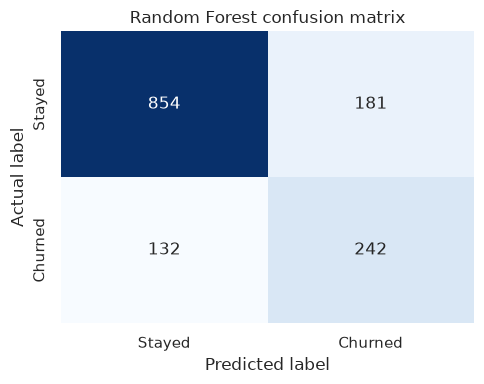

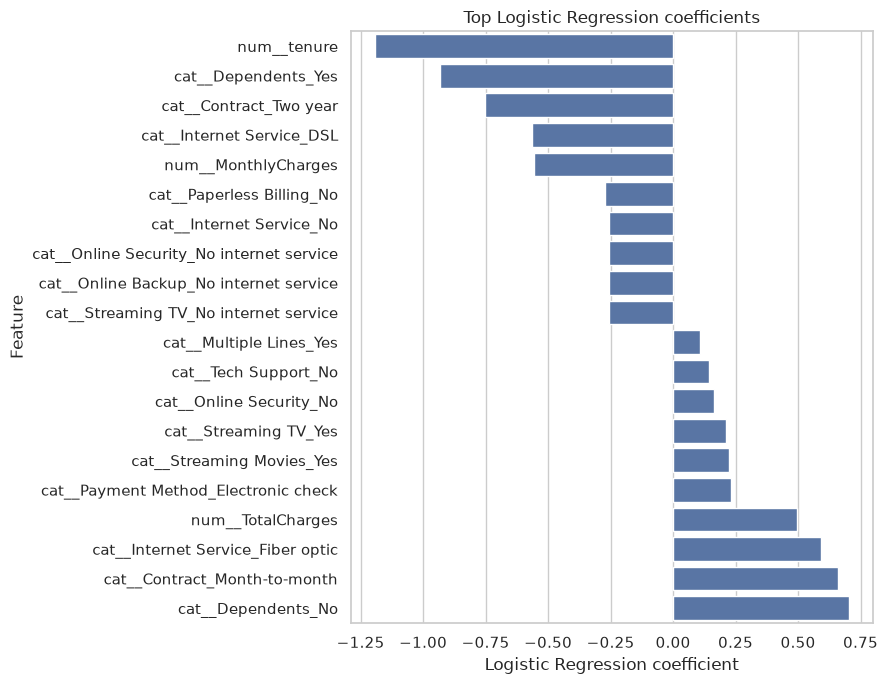


Most important features:
                               Feature  Coefficient  Absolute Coefficient  \
0                         num__tenure       -1.193                 1.193   
10                cat__Dependents_Yes       -0.931                 0.931   
39             cat__Contract_Two year       -0.753                 0.753   
9                  cat__Dependents_No        0.704                 0.704   
37       cat__Contract_Month-to-month        0.660                 0.660   
17  cat__Internet Service_Fiber optic        0.592                 0.592   
16          cat__Internet Service_DSL       -0.563                 0.563   
1                 num__MonthlyCharges       -0.558                 0.558   
2                   num__TotalCharges        0.497                 0.497   
40          cat__Paperless Billing_No       -0.274                 0.274   

                   Direction  
0    Lower churn association  
10   Lower churn association  
39   Lower churn association  
9   Higher c

In [22]:
best_name = comparison.index[0]
best_model = fitted[best_name][0]
joblib.dump(best_model, OUT / "best_churn_model.joblib")

print(f"Selected model based on ROC-AUC: {best_name}")
print(f"ROC-AUC: {comparison.loc[best_name, 'ROC-AUC']:.3f}")
print(f"Recall: {comparison.loc[best_name, 'Recall']:.3f}")
display(comparison.style.highlight_max(
    subset=["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"]
).format("{:.3f}"))

fig, ax = plt.subplots(figsize=(7, 5))
for name, (model, prob) in fitted.items():
    RocCurveDisplay.from_predictions(y_test, prob, name=name, ax=ax)
ax.set_title("ROC curves")
plt.tight_layout()
fig.savefig(FIGURES / "roc_curves.png", dpi=150)
display(fig)
plt.close(fig)

for name, (model, prob) in fitted.items():
    predictions = model.predict(X_test)
    matrix = confusion_matrix(y_test, predictions)
    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(
        matrix,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        xticklabels=["Stayed", "Churned"],
        yticklabels=["Stayed", "Churned"],
        ax=ax,
    )
    ax.set_title(f"{name} confusion matrix")
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("Actual label")
    plt.tight_layout()
    filename = name.lower().replace(" ", "_") + "_confusion_matrix.png"
    fig.savefig(FIGURES / filename, dpi=150)
    display(fig)
    plt.close(fig)

names = best_model.named_steps["preprocessor"].get_feature_names_out()
estimator = best_model.named_steps["model"]
if hasattr(estimator, "coef_"):
    coefficients = estimator.coef_[0]
    importance = pd.DataFrame({"Feature": names, "Coefficient": coefficients})
else:
    importance = pd.DataFrame({
        "Feature": names,
        "Coefficient": estimator.feature_importances_,
    })
importance["Absolute Coefficient"] = importance["Coefficient"].abs()
importance["Direction"] = np.where(
    importance["Coefficient"] > 0,
    "Higher churn association",
    "Lower churn association",
)
importance = importance.sort_values("Absolute Coefficient", ascending=False)
importance.head(20).to_csv(OUT / "feature_importance.csv", index=False)

plot_features = pd.concat([
    importance.sort_values("Coefficient").head(10),
    importance.sort_values("Coefficient").tail(10),
]).drop_duplicates("Feature")
fig, ax = plt.subplots(figsize=(9, 7))
sns.barplot(data=plot_features, x="Coefficient", y="Feature", ax=ax)
ax.set_title("Top Logistic Regression coefficients")
ax.set_xlabel("Logistic Regression coefficient")
ax.set_ylabel("Feature")
plt.tight_layout()
fig.savefig(FIGURES / "logistic_regression_feature_importance.png", dpi=150)
display(fig)
plt.close(fig)

print("\nMost important features:\n", importance.head(10))

## 6. Business Recommendations

The EDA and model interpretation identify several segments for retention teams to investigate:

### Priority 1: Early-tenure customers
Newer customers show higher observed churn. Strengthen onboarding, early engagement, and proactive support during the first months of service.

### Priority 2: Month-to-month customers
Month-to-month customers have substantially higher churn than customers on longer contracts. Test targeted incentives that encourage longer-term contracts.

### Priority 3: Higher monthly charges
Higher monthly-charge groups show elevated churn. Review pricing, perceived value, and service quality for these customers.

### Priority 4: Electronic-check customers
Electronic-check users show higher observed churn. Simplify enrollment in automatic payment options and measure adoption.

### Priority 5: Fiber-optic customers
Fiber-optic customers show elevated churn in this dataset. Investigate service quality, technical issues, expectations, and perceived value before implementing targeted interventions.

These relationships are associations, not proof of causation. Retention experiments and cost-sensitive threshold tuning should be used before operational rollout.

The trained model and comparison outputs are saved in the `outputs/` directory for reuse.

## 7. Limitations

- The analysis uses a single historical dataset and one holdout test split.
- Observed relationships represent associations rather than causal effects.
- Customer behavior may change over time, so performance should be monitored after deployment.
- The dataset does not provide enough information to estimate the financial cost of false positives and false negatives.
- `CLTV` is excluded because its definition and calculation timing are not documented well enough to establish that it would be available independently at prediction time.

## 8. Final Summary

Logistic Regression was selected by ROC-AUC, achieving 0.849 ROC-AUC and 0.781 churn recall on the holdout set. Its interpretable coefficients provide directional associations that can help prioritize retention analysis, while future deployment should include threshold tuning, cross-validation, and ongoing performance monitoring.